In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import plotly.graph_objects as go

In [2]:
df = pd.read_csv('placement.csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


Text(0, 0.5, 'package (in LPA)')

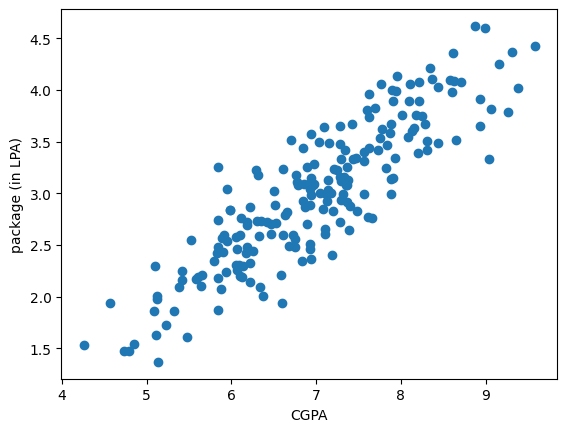

In [3]:
plt.scatter(df['cgpa'], df['package']);
plt.xlabel('CGPA')
plt.ylabel('package (in LPA)')

In [4]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print("X_test: ", X_test)

X_test:       cgpa
112  8.58
29   7.15
182  5.88
199  6.22
193  4.57
85   4.79
10   5.32
54   6.86
115  8.35
35   6.87
12   8.94
92   7.90
13   6.93
126  5.91
174  7.32
2    7.82
44   5.09
3    7.42
113  6.94
14   7.73
23   6.19
25   7.28
6    6.73
134  7.20
165  8.21
173  6.75
45   7.87
65   7.60
48   8.63
122  5.12
178  8.15
64   7.36
9    8.31
57   6.60
78   6.59
71   7.47
128  7.93
176  6.29
131  6.37
53   6.47


In [8]:
print("Y_test: ", y_test)

Y_test:  112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64


In [9]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/Users/sagnikghosh/Desktop/Machine-Learning-Concepts/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

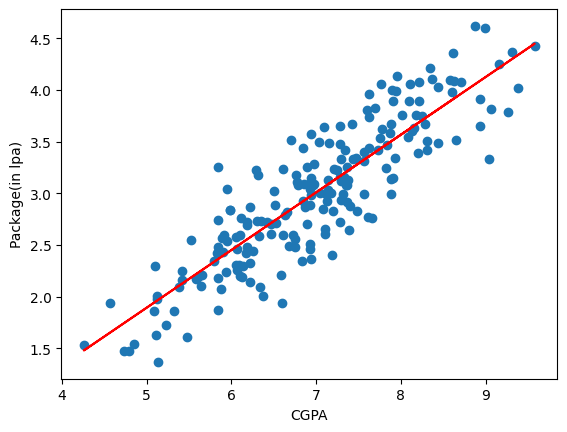

In [10]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

## Loss function in 3D

For simple linear regression, \(\hat{y} = m \cdot x + b\). We use **mean squared error (MSE)** as the loss:

\[
L(m, b) = \frac{1}{n} \sum_{i=1}^{n} \bigl(y_i - (m x_i + b)\bigr)^2
\]

Plotting \(L(m, b)\) over a grid of slopes \(m\) and intercepts \(b\) gives a bowl-shaped surface. The minimum is at the OLS solution (what `LinearRegression` finds).

In [11]:
def mse_loss(m, b, x, y):
    """MSE for y_hat = m*x + b."""
    y_pred = m * x + b
    return np.mean((y - y_pred) ** 2)


x_train_np = X_train.values.ravel()
y_train_np = y_train.values

m_opt, b_opt = lr.coef_[0], lr.intercept_

m_vals = np.linspace(-1.5, 1.5, 60) + m_opt
b_vals = np.linspace(-4, 4, 60) + b_opt
M, B = np.meshgrid(m_vals, b_vals)

x_col = x_train_np[:, np.newaxis, np.newaxis]
y_col = y_train_np[:, np.newaxis, np.newaxis]
y_pred_grid = M[np.newaxis, :, :] * x_col + B[np.newaxis, :, :]
Z = np.mean((y_col - y_pred_grid) ** 2, axis=0)

In [12]:
loss_at_optimum = mse_loss(m_opt, b_opt, x_train_np, y_train_np)

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=M,
        y=B,
        z=Z,
        colorscale="Viridis",
        opacity=0.9,
        name="MSE loss",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[m_opt],
        y=[b_opt],
        z=[loss_at_optimum],
        mode="markers",
        marker=dict(size=6, color="red"),
        name="OLS minimum (sklearn)",
    )
)
fig.update_layout(
    title="MSE loss surface L(m, b) on training data",
    scene=dict(
        xaxis_title="slope (m)",
        yaxis_title="intercept (b)",
        zaxis_title="MSE",
    ),
    width=800,
    height=700,
)
fig.show()